# Stage B validation — coverage + latency (§8.2.3)

Two views on gap-fill efficacy, evaluated for **both** Stage B candidates (RF and ST-kriging):
1. **Coverage audit** — per-month spatial coverage before and after gap-fill (§9 target: ≥ 95 %).
2. **SSO-stratified RMSE** — error vs *slots since last observed*.  Tests whether fill quality degrades gracefully as the latency widens (replaces the old DSO metric after the v3.4 30-min cadence pivot).

In [1]:
from datetime import date
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


sys.path.insert(0, str(Path.cwd()))
import validate as vb
import config as cfg

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

START = cfg.TEST_START
END   = cfg.TEST_END
print(f'Held-out window: {START} → {END}')

Held-out window: 2025-01-01 → 2026-04-30


## Coverage audit — RF vs ST-kriging vs regression-kriging

Per-month fractions:
- `pre_fill_observed` — Stage A coverage before gap-fill (same for all candidates by construction).
- `post_fill_observed` — `is_observed` flag preserved through Stage B (should ≈ pre-fill).
- `post_fill_coverage` — total valid AOD coverage after gap-fill (observed + filled).

Run separately so the file readers walk each candidate tree.  Note `rf` fills
every cell (post-fill coverage = 1.0) by design; `kriging` leaves cells with no
ST neighbours as NaN; `rf_rk` should also reach 1.0 because its gap cells fall
back to the RF drift when the residual pool is empty.

In [2]:
cov_rf = vb.coverage_audit(START, END, candidate='rf')
cov_kr = vb.coverage_audit(START, END, candidate='kriging')
cov_rk = vb.coverage_audit(START, END, candidate='rf_rk')
print('— RF —')
display(cov_rf)
print('— ST-kriging —')
display(cov_kr)
print('— RF + regression kriging —')
display(cov_rk)

— RF —


,month,n_slots_in_month,pre_fill_observed,post_fill_observed,post_fill_coverage
0,2025-01,18.161290,0.135180,0.135180,1.0
1,2025-02,18.500000,0.094623,0.094623,1.0
2,2025-03,19.161290,0.098161,0.098161,1.0
3,2025-04,20.166667,0.064013,0.064013,1.0
4,2025-05,20.290323,0.039564,0.039564,1.0
5,2025-06,20.466667,0.025743,0.025743,1.0
6,2025-07,20.290323,0.026167,0.026167,1.0
7,2025-08,20.129032,0.027882,0.027882,1.0
8,2025-09,19.566667,0.031072,0.031072,1.0
9,2025-10,19.064516,0.041017,0.041017,1.0


— ST-kriging —


,month,n_slots_in_month,pre_fill_observed,post_fill_observed,post_fill_coverage
0,2025-01,18.161290,0.135180,0.135180,0.914841
1,2025-02,18.500000,0.094623,0.094623,0.823985
2,2025-03,19.161290,0.098161,0.098161,0.871803
3,2025-04,20.166667,0.064013,0.064013,0.919165
4,2025-05,20.290323,0.039564,0.039564,0.862147
5,2025-06,20.466667,0.025743,0.025743,0.736757
6,2025-07,20.290323,0.026167,0.026167,0.727257
7,2025-08,20.129032,0.027882,0.027882,0.737840
8,2025-09,19.566667,0.031072,0.031072,0.780499
9,2025-10,19.064516,0.041017,0.041017,0.805259


— RF + regression kriging —


,month,n_slots_in_month,pre_fill_observed,post_fill_observed,post_fill_coverage
0,2025-01,18.161290,0.135180,0.135180,1.0
1,2025-02,18.500000,0.094623,0.094623,1.0
2,2025-03,19.161290,0.098161,0.098161,1.0
3,2025-04,20.166667,0.064013,0.064013,1.0
4,2025-05,20.290323,0.039564,0.039564,1.0
5,2025-06,20.466667,0.025743,0.025743,1.0
6,2025-07,20.290323,0.026167,0.026167,1.0
7,2025-08,20.129032,0.027882,0.027882,1.0
8,2025-09,19.566667,0.031072,0.031072,1.0
9,2025-10,19.064516,0.041017,0.041017,1.0


### Side-by-side post-fill coverage

Merges the two audits on `month`.  `pre_fill_observed` is taken from one side (identical by construction); a discrepancy here would signal a Stage A → Stage B IO bug.

In [3]:
cov_side = (cov_rf[['month', 'pre_fill_observed', 'post_fill_coverage']]
            .rename(columns={'post_fill_coverage': 'post_fill_rf'})
            .merge(cov_kr[['month', 'post_fill_coverage']]
                   .rename(columns={'post_fill_coverage': 'post_fill_kriging'}),
                   on='month')
            .merge(cov_rk[['month', 'post_fill_coverage']]
                   .rename(columns={'post_fill_coverage': 'post_fill_rf_rk'}),
                   on='month'))
cov_side['delta_rf_minus_kr']    = cov_side['post_fill_rf']    - cov_side['post_fill_kriging']
cov_side['delta_rf_rk_minus_kr'] = cov_side['post_fill_rf_rk'] - cov_side['post_fill_kriging']
cov_side

,month,pre_fill_observed,post_fill_rf,post_fill_kriging,post_fill_rf_rk,delta_rf_minus_kr,delta_rf_rk_minus_kr
0,2025-01,0.135180,1.0,0.914841,1.0,0.085159,0.085159
1,2025-02,0.094623,1.0,0.823985,1.0,0.176015,0.176015
2,2025-03,0.098161,1.0,0.871803,1.0,0.128197,0.128197
3,2025-04,0.064013,1.0,0.919165,1.0,0.080835,0.080835
4,2025-05,0.039564,1.0,0.862147,1.0,0.137853,0.137853
5,2025-06,0.025743,1.0,0.736757,1.0,0.263243,0.263243
6,2025-07,0.026167,1.0,0.727257,1.0,0.272743,0.272743
7,2025-08,0.027882,1.0,0.737840,1.0,0.262160,0.262160
8,2025-09,0.031072,1.0,0.780499,1.0,0.219501,0.219501
9,2025-10,0.041017,1.0,0.805259,1.0,0.194741,0.194741


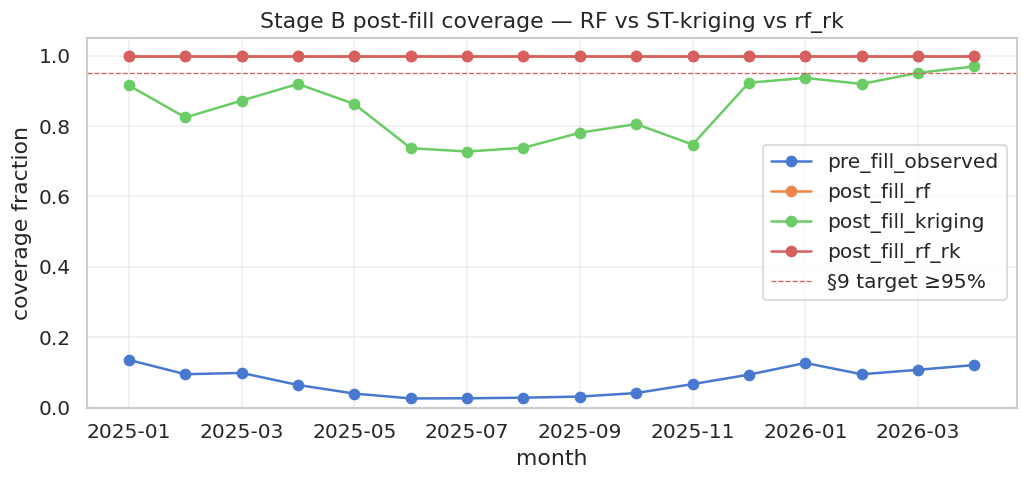

In [4]:
if not cov_side.empty:
    ax = cov_side.plot(x='month',
                       y=['pre_fill_observed', 'post_fill_rf', 'post_fill_kriging',
                          'post_fill_rf_rk'],
                       kind='line', marker='o', figsize=(10, 4))
    ax.axhline(0.95, color='r', ls='--', lw=0.8, label='§9 target ≥95%')
    ax.set_ylim(0, 1.05); ax.set_ylabel('coverage fraction')
    ax.set_title('Stage B post-fill coverage — RF vs ST-kriging vs rf_rk')
    ax.legend(); ax.grid(alpha=0.3)

## SSO-stratified RMSE

For each AERONET-blind pair, count slot-steps back to the nearest observed slot at the same `(site, cell)`, including the nighttime gap if no earlier slot exists today.  RMSE binned by SSO answers: *does the fill quality degrade gracefully as the gap widens?*

In [5]:
pairs_rf = vb.aeronet_pairs(START, END, candidate='rf', blind_only=True)
vb.sso_stratified_rmse(pairs_rf)

,N,R,R2,RMSE,MAE,Bias,pct_EE,label,sso_bin,count
0,633,0.789224,0.525324,0.350599,0.195226,0.023189,36.176935,1 slot,1 slot,633
1,3,NaN,NaN,NaN,NaN,NaN,NaN,≤2 h,≤2 h,3


In [6]:
pairs_rf = vb.aeronet_pairs(START, END, candidate='kriging', blind_only=True)
vb.sso_stratified_rmse(pairs_rf)

,N,R,R2,RMSE,MAE,Bias,pct_EE,label,sso_bin,count
0,628,0.860045,0.724444,0.267895,0.174546,0.044368,38.216561,1 slot,1 slot,628
1,3,NaN,NaN,NaN,NaN,NaN,NaN,≤2 h,≤2 h,3


In [7]:
pairs_rk = vb.aeronet_pairs(START, END, candidate='rf_rk', blind_only=True)
vb.sso_stratified_rmse(pairs_rk)

,N,R,R2,RMSE,MAE,Bias,pct_EE,label,sso_bin,count
0,633,0.853199,0.700274,0.278595,0.189362,0.060998,32.543444,1 slot,1 slot,633
1,3,NaN,NaN,NaN,NaN,NaN,NaN,≤2 h,≤2 h,3
